# Análisis Exploratorio de Datos — Heart Disease Dataset

Proyecto académico: detección temprana de enfermedades cardiovasculares usando el Heart Disease Dataset del UCI Machine Learning Repository.


## 1. Instalación e importación de librerías

In [2]:
!pip -q install ucimlrepo

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 2. Descarga del dataset usando `ucimlrepo`

In [3]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets
metadata = heart_disease.metadata
variables = heart_disease.variables

## 3. Significado de `X`, `y`, `metadata` y `variables`

- `X`: matriz de características. Contiene las variables clínicas predictoras que puede usar un modelo.
- `y`: variable objetivo. En este dataset, el objetivo original es `num`, que indica la severidad del diagnóstico de enfermedad cardiovascular.
- `metadata`: información general del dataset, como fuente, descripción y detalles del repositorio.
- `variables`: diccionario de datos con nombres de variables, roles, tipos, descripciones y unidades cuando están disponibles.

In [4]:
print("Nombre del dataset:", metadata.get("name"))
print("URL del repositorio:", metadata.get("repository_url"))

variables

Nombre del dataset: Heart Disease
URL del repositorio: https://archive.ics.uci.edu/dataset/45/heart+disease


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


## 4. Unión de features y target en `df`

In [5]:
df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 5. Exploración inicial

In [6]:
df.shape

(303, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [9]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


## 6. Detección de valores faltantes

In [10]:
missing_values = (
    df.isna()
    .sum()
    .to_frame(name="cantidad_faltantes")
    .assign(porcentaje_faltantes=lambda data: data["cantidad_faltantes"] / len(df) * 100)
    .sort_values("cantidad_faltantes", ascending=False)
)

missing_values

,cantidad_faltantes,porcentaje_faltantes
ca,4,1.320132
thal,2,0.660066
cp,0,0.000000
trestbps,0,0.000000
age,0,0.000000
sex,0,0.000000
fbs,0,0.000000
chol,0,0.000000
restecg,0,0.000000
thalach,0,0.000000


## 7. Detección de filas duplicadas

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Filas duplicadas: {duplicate_count}")

Filas duplicadas: 0


## 8. Estadísticas descriptivas

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 9. Distribución de la variable objetivo: `num`

La variable original `num` es multiclase:

- `0`: sin enfermedad cardiovascular.
- `1`, `2`, `3`, `4`: diferentes niveles de presencia/severidad de enfermedad cardiovascular.

,cantidad
num,
0,164
1,55
2,36
3,35
4,13


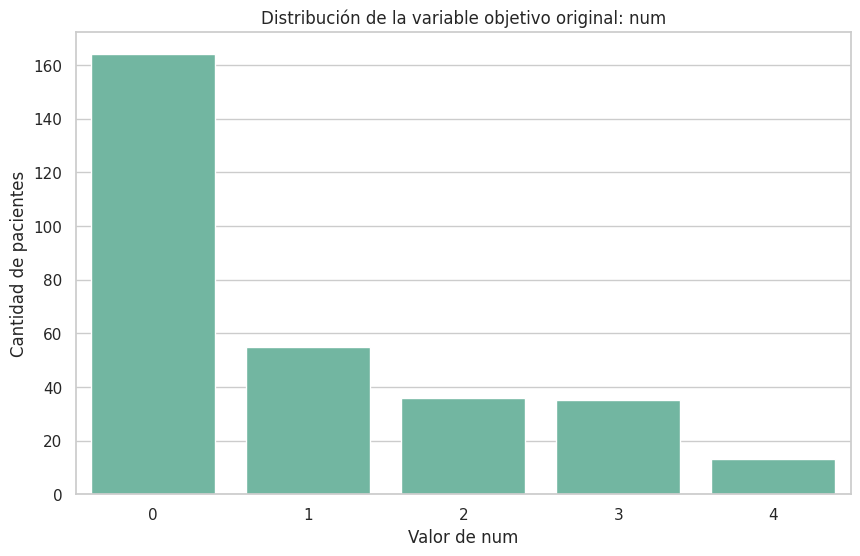

In [13]:
num_counts = df["num"].value_counts().sort_index()

display(num_counts.to_frame(name="cantidad"))

ax = sns.countplot(data=df, x="num", order=num_counts.index)
ax.set_title("Distribución de la variable objetivo original: num")
ax.set_xlabel("Valor de num")
ax.set_ylabel("Cantidad de pacientes")
plt.show()

## 10. Creación de la variable objetivo binaria

Para clasificación binaria:

- `0`: sin enfermedad.
- `1`: presencia de enfermedad.

,cantidad
target,
0,164
1,139


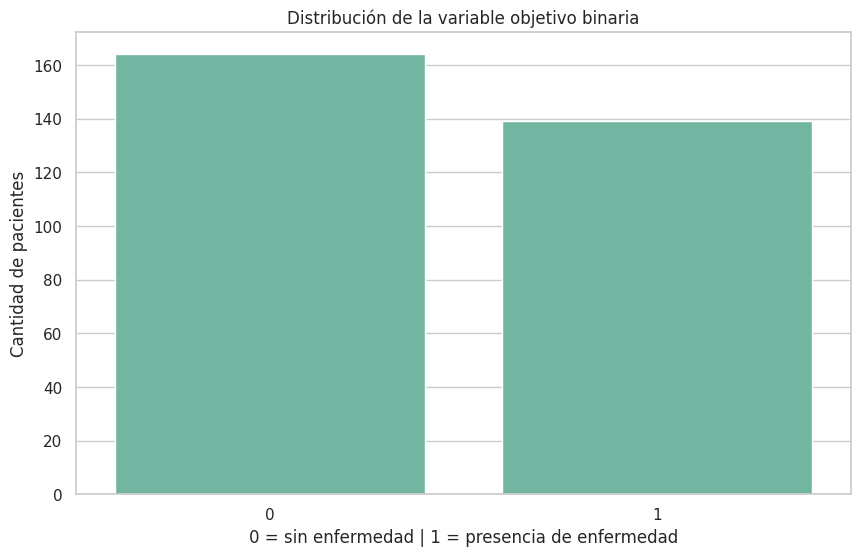

In [14]:
df["target"] = (df["num"] > 0).astype(int)

target_counts = df["target"].value_counts().sort_index()
display(target_counts.to_frame(name="cantidad"))

ax = sns.countplot(data=df, x="target", order=[0, 1])
ax.set_title("Distribución de la variable objetivo binaria")
ax.set_xlabel("0 = sin enfermedad | 1 = presencia de enfermedad")
ax.set_ylabel("Cantidad de pacientes")
plt.show()

## 11. Histogramas de variables numéricas

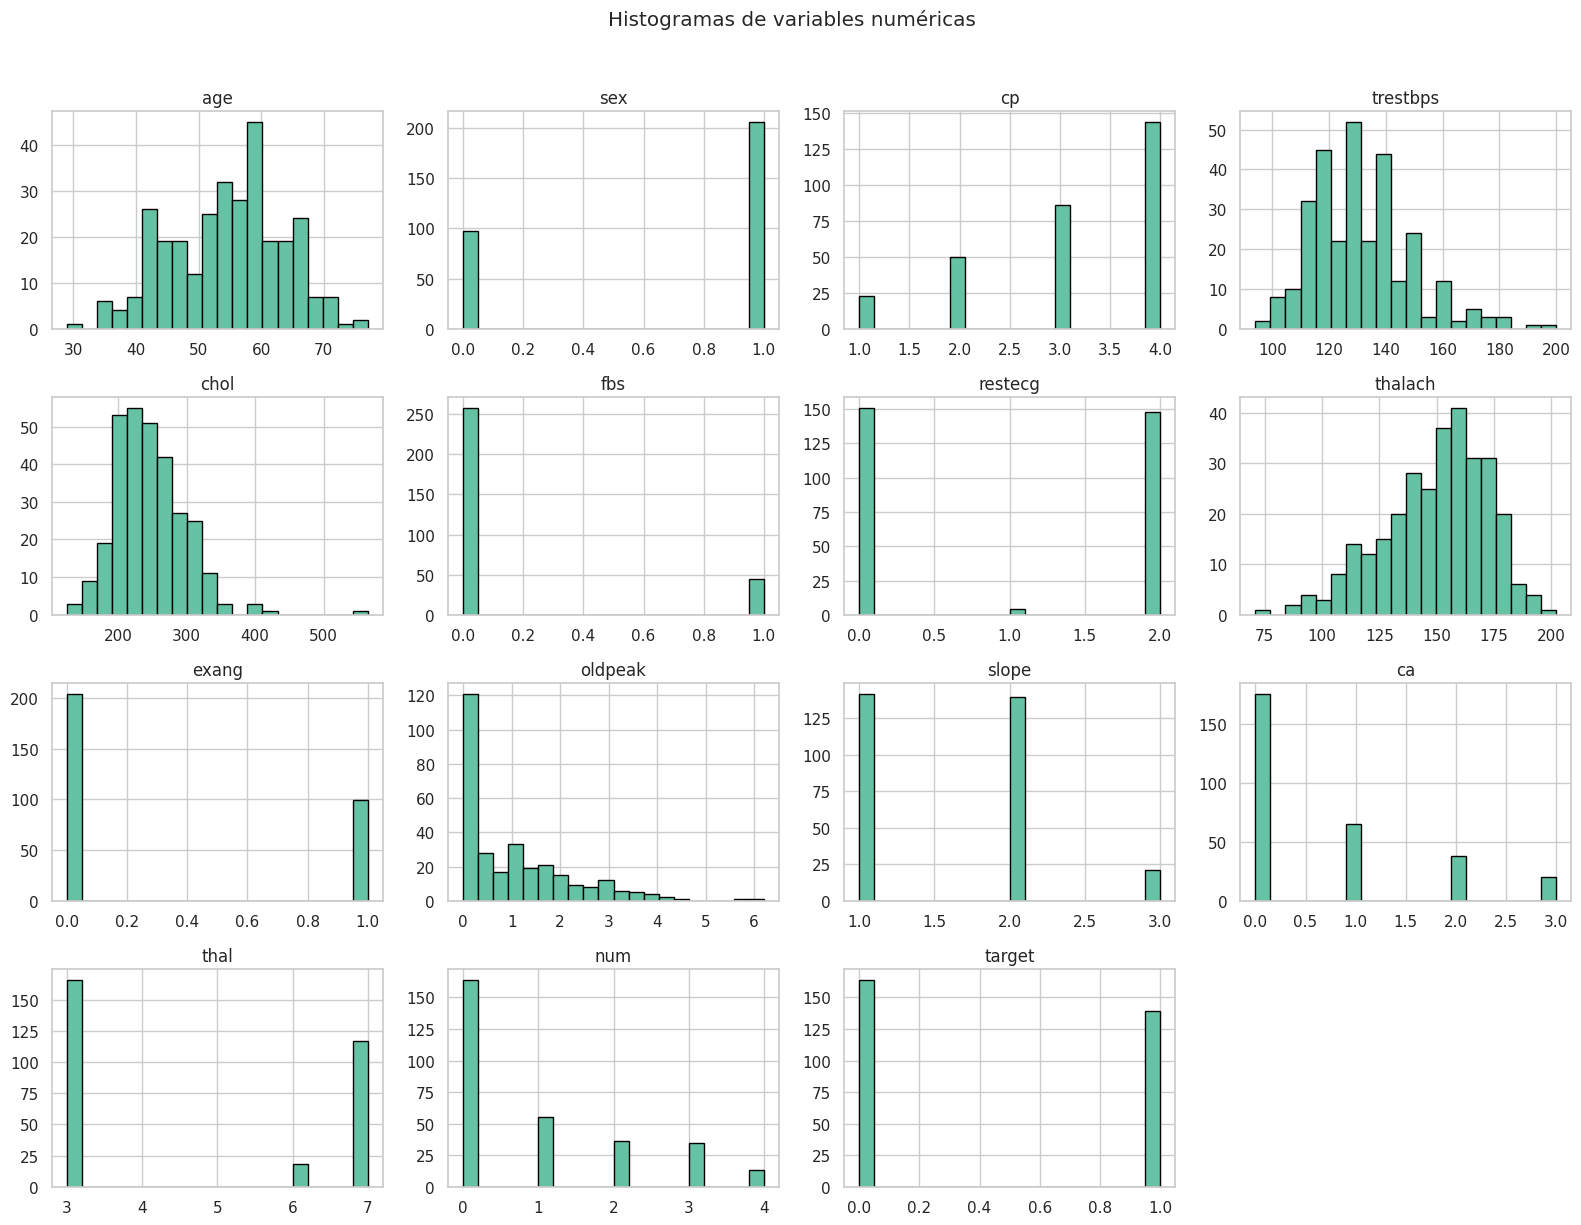

In [15]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()

df[numeric_columns].hist(bins=20, figsize=(16, 12), edgecolor="black")
plt.suptitle("Histogramas de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

## 12. Matriz de correlación con Seaborn

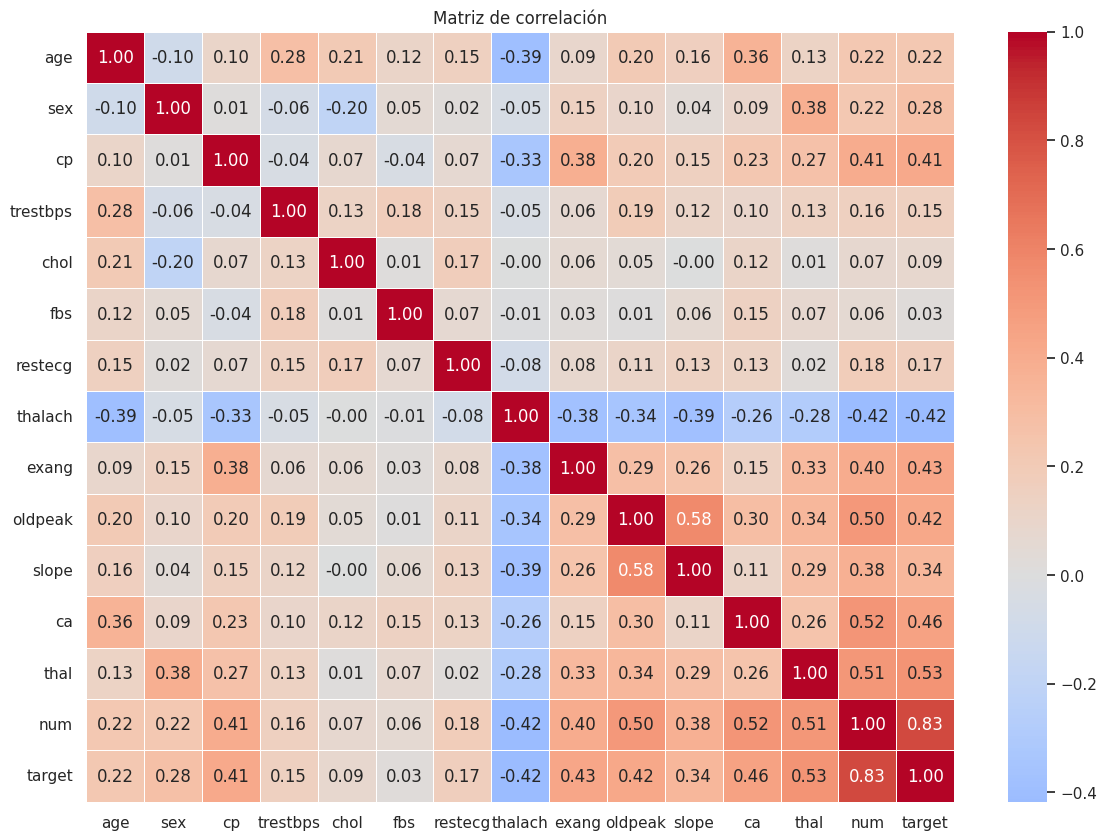

In [16]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Matriz de correlación")
plt.show()

## 13. Boxplots: variables clínicas vs. variable objetivo binaria

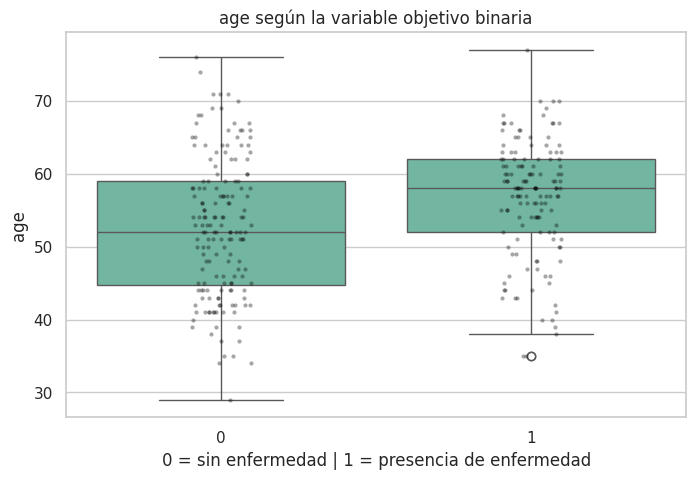

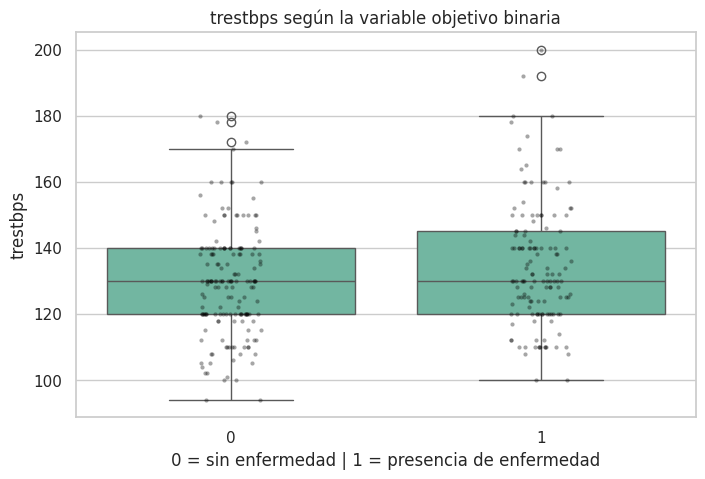

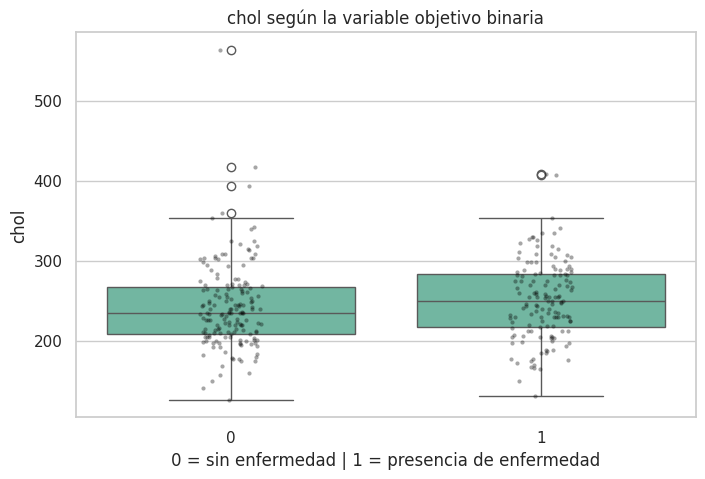

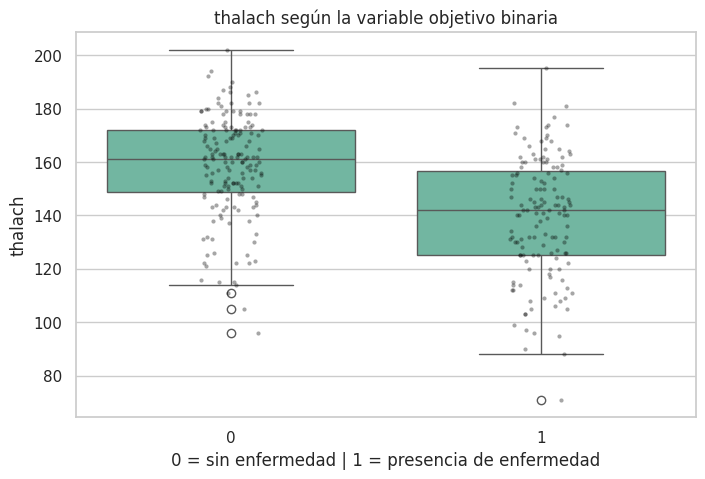

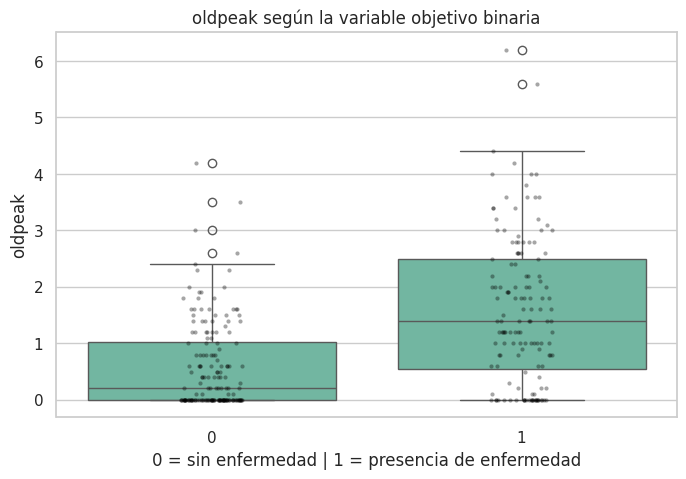

In [17]:
clinical_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
clinical_columns = [column for column in clinical_columns if column in df.columns]

for column in clinical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="target", y=column)
    sns.stripplot(data=df, x="target", y=column, color="black", alpha=0.35, size=3)
    plt.title(f"{column} según la variable objetivo binaria")
    plt.xlabel("0 = sin enfermedad | 1 = presencia de enfermedad")
    plt.ylabel(column)
    plt.show()

## 14. Conclusiones automáticas del EDA

In [ ]:
def build_eda_conclusions(dataframe: pd.DataFrame) -> list[str]:
    """Construye conclusiones automáticas y concisas a partir del EDA.

    Parámetros
    ----------
    dataframe : pd.DataFrame
        Dataset de enfermedades cardiovasculares que contiene la variable
        objetivo original `num` y la variable binaria `target`.

    Retorna
    -------
    list[str]
        Conclusiones legibles y útiles para el reporte del EDA.
    """
    rows, columns = dataframe.shape
    missing_total = int(dataframe.isna().sum().sum())
    duplicate_total = int(dataframe.duplicated().sum())
    disease_rate = dataframe["target"].mean() * 100

    target_correlations = (
        dataframe.select_dtypes(include="number")
        .corr(numeric_only=True)["target"]
        .drop(labels=["target", "num"], errors="ignore")
        .dropna()
        .sort_values(key=lambda values: values.abs(), ascending=False)
    )

    strongest_features = target_correlations.head(3)
    feature_summary = ", ".join(
        f"{feature} (r={correlation:.2f})"
        for feature, correlation in strongest_features.items()
    )

    conclusions = [
        f"El dataset contiene {rows} pacientes y {columns} columnas después de agregar la variable objetivo binaria.",
        f"El dataset tiene {missing_total} valores faltantes y {duplicate_total} filas duplicadas.",
        f"La prevalencia de enfermedad en la variable objetivo binaria es aproximadamente {disease_rate:.1f}%.",
        f"Las variables con mayor correlación frente a la variable objetivo binaria son: {feature_summary}.",
        "La variable original `num` no debe usarse junto con `target` como predictora, porque codifica directamente el diagnóstico.",
        "Antes del modelado, se deben tratar los valores faltantes y codificar correctamente las variables categóricas.",
    ]

    return conclusions


for index, conclusion in enumerate(build_eda_conclusions(df), start=1):
    print(f"{index}. {conclusion}")

1. El dataset contiene 303 pacientes y 15 columnas después de agregar la variable objetivo binaria.
2. El dataset tiene 6 valores faltantes y 0 filas duplicadas.
3. La prevalencia de enfermedad en la variable objetivo binaria es aproximadamente 45.9%.
4. Las variables con mayor correlación frente a la variable objetivo binaria son: thal (r=0.53), ca (r=0.46), exang (r=0.43).
5. La variable original `num` no debe usarse junto con `target` como predictora, porque codifica directamente el diagnóstico.
6. Antes del modelado, se deben tratar los valores faltantes y codificar correctamente las variables categóricas.
